# CV_PR3 — Deep Learning / Computer Vision Practical

**Student-friendly complete notebook template**

This notebook follows the project sheet in the uploaded PR3 document and keeps the task order:

1. Environment setup, image loading & morphological operations
2. Bitwise operations & image histograms
3. Face detection with YuNet (OpenCV)
4. Object detection with YOLOv8n
5. Integrated pipeline & final comparison
6. Viva questions and short answers

> **Important:** Run the notebook from top to bottom. Put your own images in `data/images/`. The notebook creates `data/models/` automatically for the YuNet model. YOLOv8n weights are downloaded automatically by Ultralytics on first use.

**Project file name:** `CV_PR3.ipynb`


## Dataset / files required

Recommended folder structure:

```text
CV_PR3/
├── CV_PR3.ipynb
├── data/
│   ├── images/
│   │   ├── morphology.jpg
│   │   ├── bitwise.jpg
│   │   ├── face1.jpg
│   │   ├── face2.jpg
│   │   ├── objects1.jpg
│   │   └── objects2.jpg
│   └── models/
│       └── face_detection_yunet_2023mar.onnx
├── plots/
└── requirements.txt
```

Use **3–4 face images** with different pose/lighting/occlusion for YuNet and **2–3 object images** containing COCO objects such as person, car, dog, bottle, chair, etc.


In [ ]:
# Project setup
from pathlib import Path
import time
import urllib.request

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
IMG_DIR = DATA_DIR / "images"
MODEL_DIR = DATA_DIR / "models"
PLOTS_DIR = BASE_DIR / "plots"

for directory in (IMG_DIR, MODEL_DIR, PLOTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print("Project folders are ready.")


OpenCV version: 5.0.0
NumPy version: 2.2.5
Image folder: c:\Deep Learning\PR-3\data\images
Model folder: c:\Deep Learning\PR-3\data\models
Plots folder: c:\Deep Learning\PR-3\plots


In [2]:
# Reusable display / file helpers
def show_image(image, title="Image", cmap=None, size=(8, 6)):
    plt.figure(figsize=size)
    if image.ndim == 3:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(image, cmap=cmap if cmap else "gray")
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

def save_plot(filename):
    output_path = PLOTS_DIR / filename
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    print("Saved:", output_path)

def load_image(filename):
    image_path = IMG_DIR / filename
    image = cv2.imread(str(image_path))
    if image is None:
        raise FileNotFoundError(f"Unable to read: {image_path}")
    print(f"{filename}: {image.shape}")
    return image

image_files = sorted(
    file.name for file in IMG_DIR.iterdir()
    if file.is_file() and file.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
)

print("Available images:", image_files)


Images found: ['face1.jpg', 'face2.jpg', 'face3.jpg', 'fruits.png', 'morphology.jpg', 'objects1.jpg', 'objects2.jpg']


# Task 1 — Environment Setup, Image Loading & Morphological Operations

### Objective
Understand how erosion, dilation, opening and closing can clean or modify a binary image before a detector receives it.

### Expected output
A binary image, a 1×5 morphology comparison, a 3×3 kernel-shape/size comparison grid, and a Markdown explanation of the four operations.


morphology.jpg: shape=(3472, 2747, 3), dtype=uint8
Saved: c:\Deep Learning\PR-3\plots\task1_binary.png


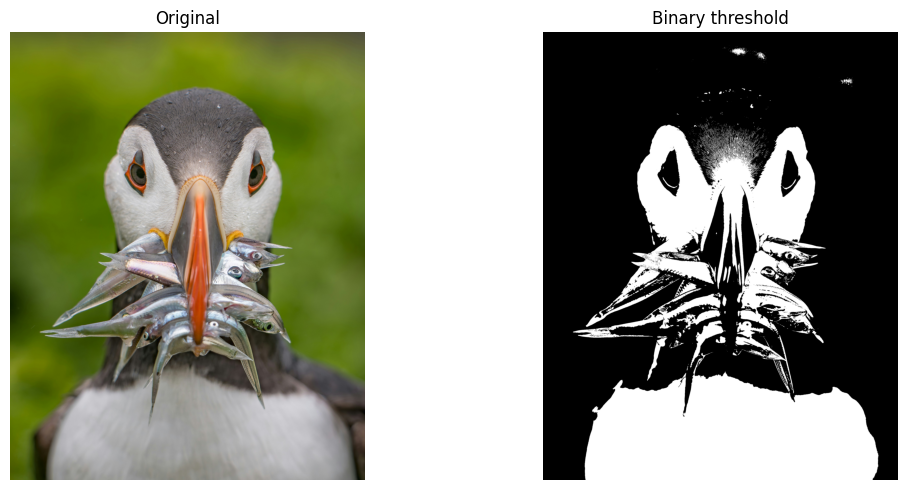

In [ ]:
# Task 1: convert the selected image into a binary image
morph_file = "morphology.jpg"
if not (IMG_DIR / morph_file).exists():
    morph_file = image_files[0] if image_files else None

if morph_file is None:
    raise FileNotFoundError("No image is available in data/images/.")

original = load_image(morph_file)
gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)

threshold_value = 127
_, binary = cv2.threshold(gray, threshold_value, 255, cv2.THRESH_BINARY)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[1].imshow(binary, cmap="gray")
axes[1].set_title(f"Binary (threshold={threshold_value})")

for axis in axes:
    axis.axis("off")

plt.tight_layout()
save_plot("task1_binary.png")
plt.show()

# Keep the original variable name available for later tasks.
img = original


Saved: c:\Deep Learning\PR-3\plots\task1_morphology_1x5.png


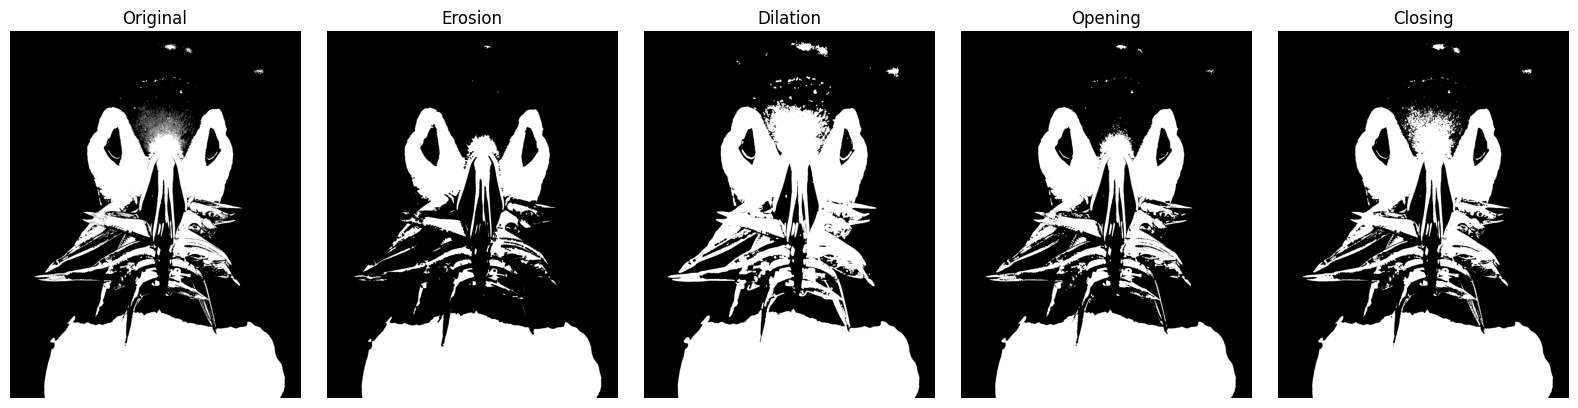

In [ ]:
# Task 1: basic morphological operations
kernel_5 = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

operations = {
    "Original": binary,
    "Erosion": cv2.morphologyEx(binary, cv2.MORPH_ERODE, kernel_5, iterations=2),
    "Dilation": cv2.morphologyEx(binary, cv2.MORPH_DILATE, kernel_5, iterations=2),
    "Opening": cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel_5),
    "Closing": cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel_5),
}

fig, axes = plt.subplots(1, len(operations), figsize=(16, 4))
for axis, (name, result) in zip(axes, operations.items()):
    axis.imshow(result, cmap="gray")
    axis.set_title(name)
    axis.axis("off")

plt.tight_layout()
save_plot("task1_morphology_1x5.png")
plt.show()


### Why morphology works

- **Erosion:** shrinks white foreground regions. It removes small white noise and is useful when objects have tiny unwanted protrusions. It behaves like a local minimum operation for binary/grayscale morphology.
- **Dilation:** expands white foreground regions. It can fill small gaps, connect nearby components and recover thin parts after erosion.
- **Opening = erosion → dilation:** removes small bright/salt noise while preserving the main shape reasonably well. A practical use is cleaning a noisy foreground mask before detection.
- **Closing = dilation → erosion:** fills small dark holes and gaps inside foreground objects. A practical use is repairing broken regions in a segmentation mask before passing it downstream.

For a noisy camera mask, **opening** is usually useful for removing small isolated white noise, while **closing** is useful for filling small holes or broken dark regions.


Saved: c:\Deep Learning\PR-3\plots\task1_kernel_comparison.png


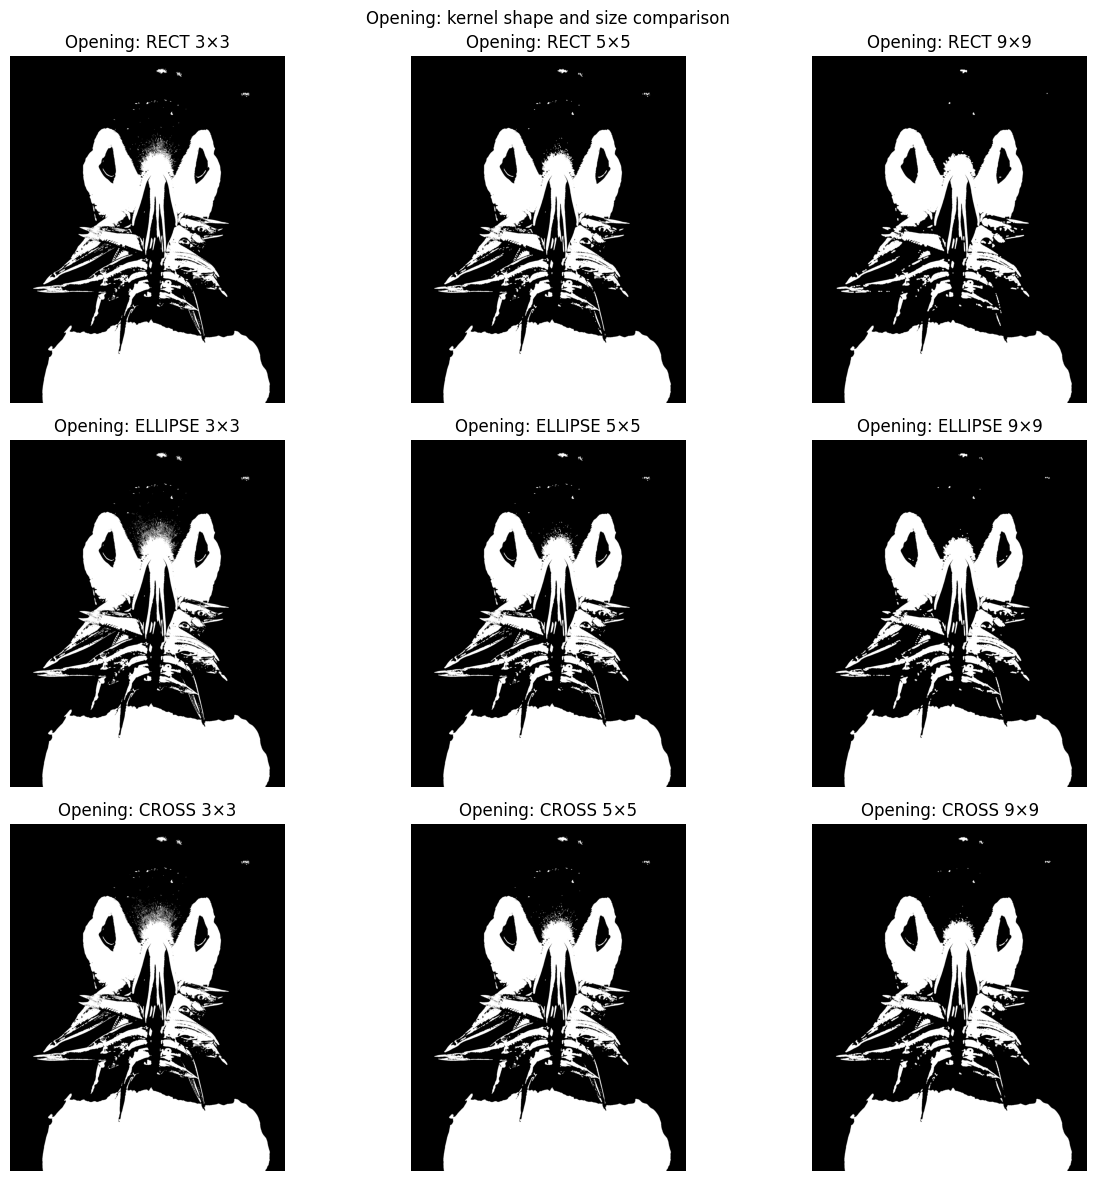

Tip: For salt-and-pepper noise, choose the smallest kernel that removes noise without noticeably shrinking object boundaries.


In [ ]:
# Task 1: compare structuring-element shapes and sizes
kernel_types = {
    "RECT": cv2.MORPH_RECT,
    "ELLIPSE": cv2.MORPH_ELLIPSE,
    "CROSS": cv2.MORPH_CROSS,
}
kernel_sizes = (3, 5, 9)

fig, axes = plt.subplots(3, 3, figsize=(12, 11))

for row, (shape_name, shape_code) in enumerate(kernel_types.items()):
    for col, size in enumerate(kernel_sizes):
        element = cv2.getStructuringElement(shape_code, (size, size))
        opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, element)

        axes[row, col].imshow(opened, cmap="gray")
        axes[row, col].set_title(f"{shape_name} {size}×{size}")
        axes[row, col].axis("off")

plt.suptitle("Opening with different kernel shapes and sizes")
plt.tight_layout()
save_plot("task1_kernel_comparison.png")
plt.show()

print("Smaller kernels normally preserve more of the original shape.")


# Task 2 — Bitwise Operations & Image Histograms

### Objective
Use binary masks for logical image operations and use histograms to understand intensity distribution, brightness and contrast.

### Expected output
A 2×3 bitwise grid, a masked-image example, grayscale and B/G/R histograms, and brightness/contrast comparisons.


Saved: c:\Deep Learning\PR-3\plots\task2_bitwise_grid.png


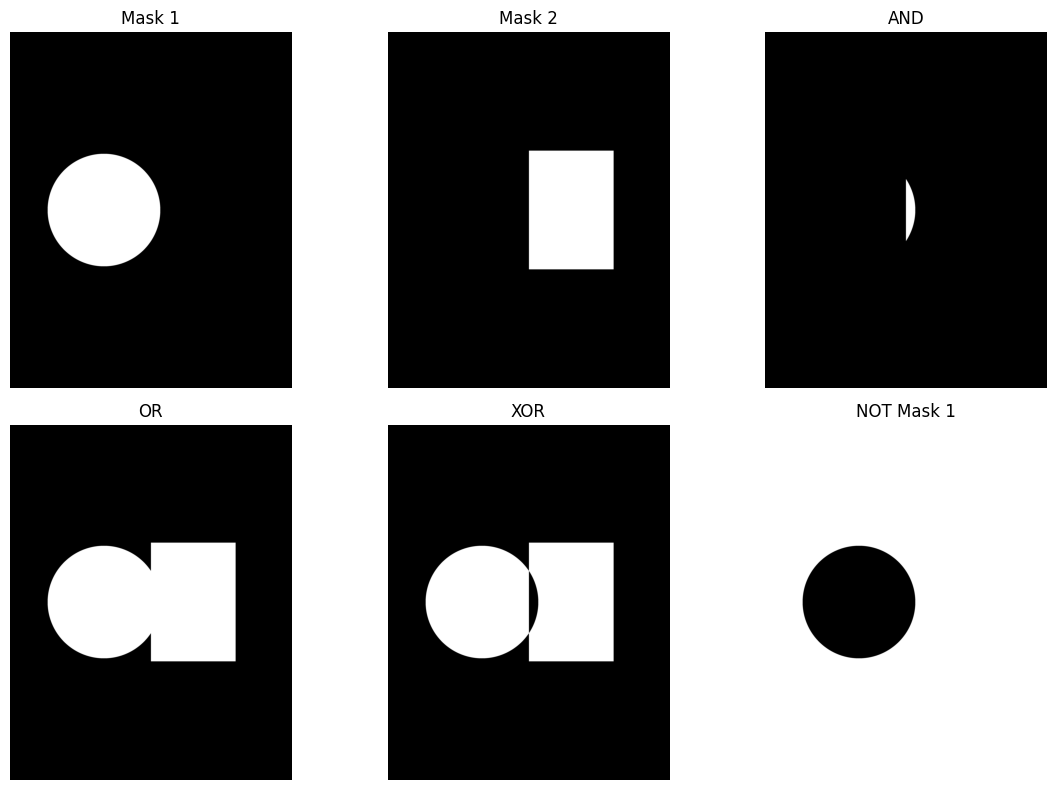

In [ ]:
# Task 2: create two binary masks and apply logical operations
mask_canvas = np.zeros(binary.shape, dtype=np.uint8)
mask_a = mask_canvas.copy()
mask_b = mask_canvas.copy()

height, width = mask_canvas.shape
cv2.circle(mask_a, (width // 3, height // 2), min(height, width) // 5, 255, -1)
cv2.rectangle(
    mask_b,
    (width // 2, height // 3),
    (width * 4 // 5, height * 2 // 3),
    255,
    -1
)

bitwise_results = {
    "Mask A": mask_a,
    "Mask B": mask_b,
    "AND": cv2.bitwise_and(mask_a, mask_b),
    "OR": cv2.bitwise_or(mask_a, mask_b),
    "XOR": cv2.bitwise_xor(mask_a, mask_b),
    "NOT A": cv2.bitwise_not(mask_a),
}

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for axis, (name, result) in zip(axes.ravel(), bitwise_results.items()):
    axis.imshow(result, cmap="gray")
    axis.set_title(name)
    axis.axis("off")

plt.tight_layout()
save_plot("task2_bitwise_grid.png")
plt.show()


Saved: c:\Deep Learning\PR-3\plots\task2_masked_region.png


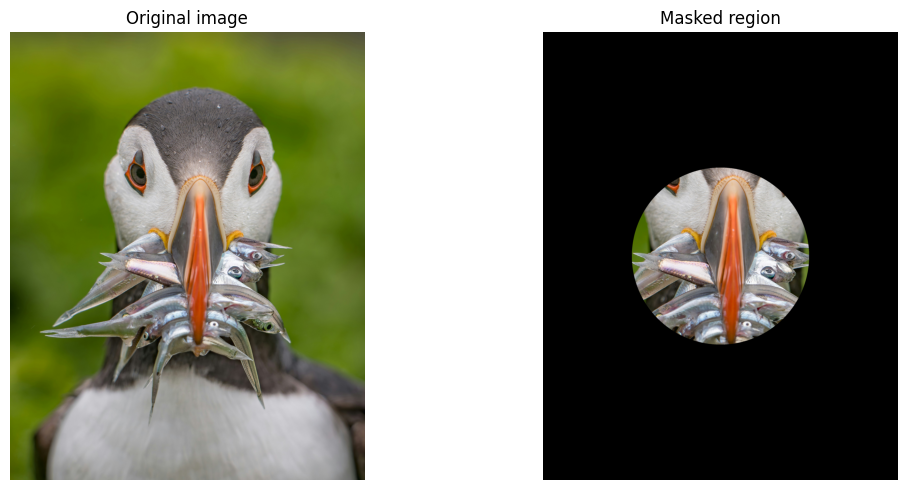

In [ ]:
# Task 2: use a circular mask to extract an ROI
source = img.copy()
roi_mask = np.zeros(source.shape[:2], dtype=np.uint8)

center_x = source.shape[1] // 2
center_y = source.shape[0] // 2
roi_radius = min(source.shape[:2]) // 4

cv2.circle(roi_mask, (center_x, center_y), roi_radius, 255, -1)
masked_region = cv2.bitwise_and(source, source, mask=roi_mask)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(source, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[1].imshow(cv2.cvtColor(masked_region, cv2.COLOR_BGR2RGB))
axes[1].set_title("Circular masked region")

for axis in axes:
    axis.axis("off")

plt.tight_layout()
save_plot("task2_masked_region.png")
plt.show()


Saved: c:\Deep Learning\PR-3\plots\task2_grayscale_histogram.png


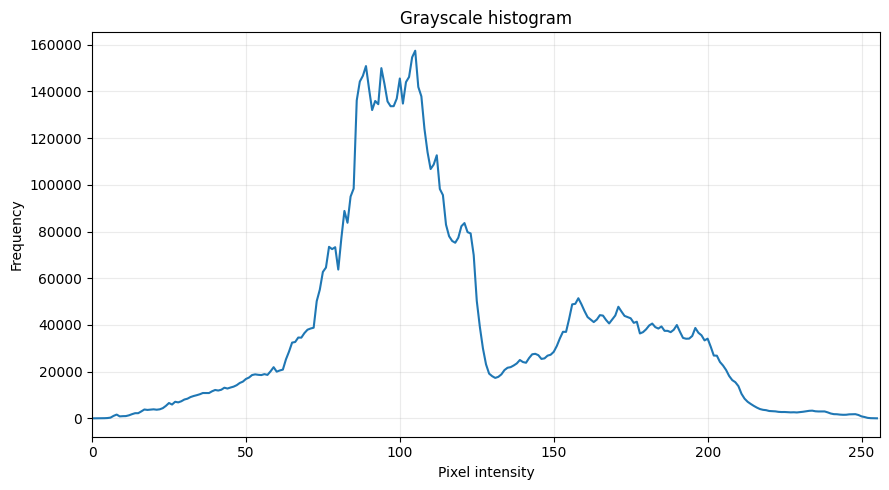

Saved: c:\Deep Learning\PR-3\plots\task2_bgr_histogram.png


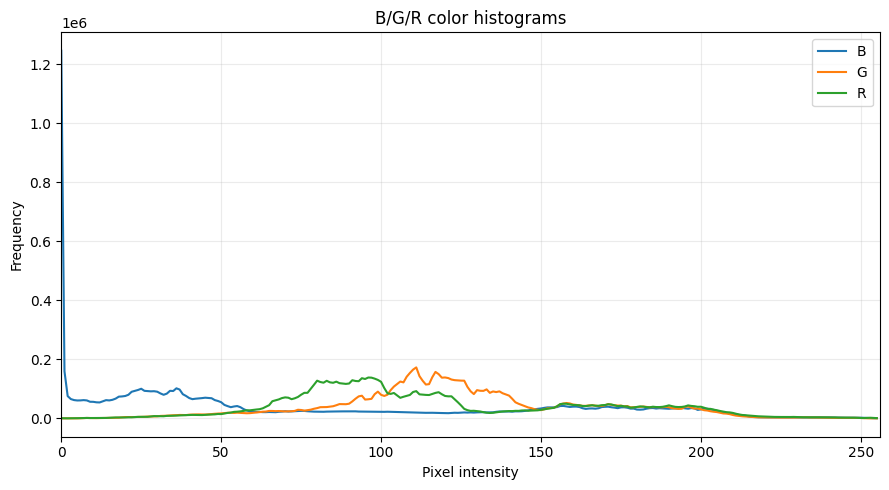

In [ ]:
# Task 2: grayscale and B/G/R histograms
gray_values, gray_counts = np.unique(gray, return_counts=True)

gray_hist = np.zeros(256, dtype=np.int64)
gray_hist[gray_values] = gray_counts

plt.figure(figsize=(9, 5))
plt.plot(np.arange(256), gray_hist)
plt.title("Grayscale histogram")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")
plt.xlim(0, 255)
plt.grid(alpha=0.25)
plt.tight_layout()
save_plot("task2_grayscale_histogram.png")
plt.show()

plt.figure(figsize=(9, 5))
for channel_name, channel_index in {"Blue": 0, "Green": 1, "Red": 2}.items():
    values, counts = np.unique(source[:, :, channel_index], return_counts=True)
    histogram = np.zeros(256, dtype=np.int64)
    histogram[values] = counts
    plt.plot(histogram, label=channel_name)

plt.title("B/G/R color histograms")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")
plt.xlim(0, 255)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
save_plot("task2_bgr_histogram.png")
plt.show()


Saved: c:\Deep Learning\PR-3\plots\task2_brightness_contrast.png


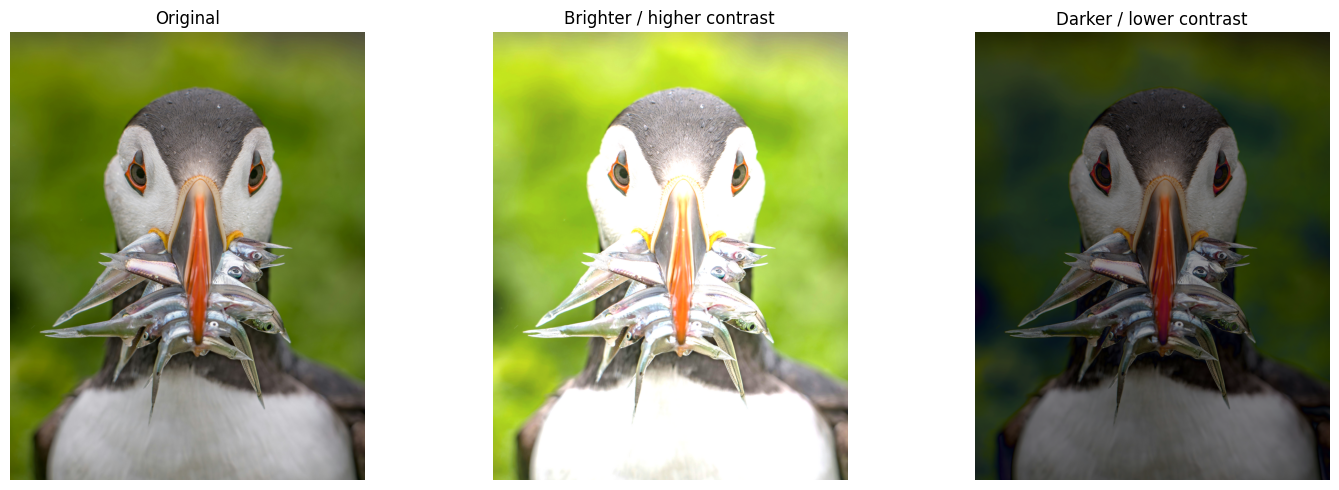

Saved: c:\Deep Learning\PR-3\plots\task2_before_after_histograms.png


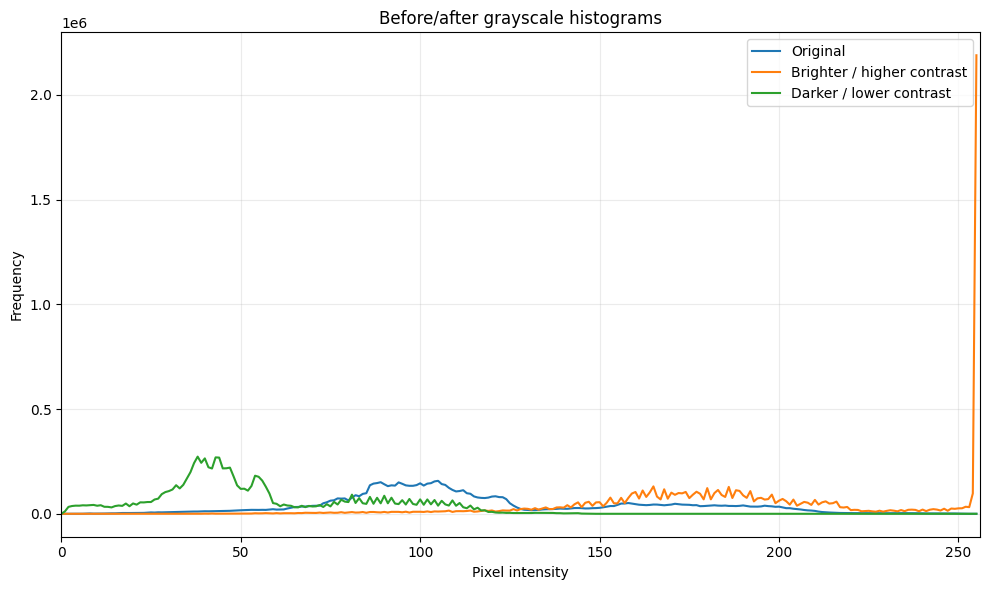

In [ ]:
# Task 2: brightness and contrast transformation
versions = {
    "Original": source,
    "Brighter / higher contrast": cv2.convertScaleAbs(source, alpha=1.5, beta=30),
    "Darker / lower contrast": cv2.convertScaleAbs(source, alpha=0.7, beta=-30),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for axis, (title, image) in zip(axes, versions.items()):
    axis.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axis.set_title(title)
    axis.axis("off")

plt.tight_layout()
save_plot("task2_brightness_contrast.png")
plt.show()

plt.figure(figsize=(10, 6))
for title, image in versions.items():
    gray_version = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    histogram = np.bincount(gray_version.ravel(), minlength=256)
    plt.plot(histogram, label=title)

plt.title("Before / after grayscale histograms")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")
plt.xlim(0, 255)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
save_plot("task2_before_after_histograms.png")
plt.show()


### Why alpha and beta matter

The transformation is:

**new_pixel = alpha × pixel + beta**

- **alpha** controls contrast. Values above 1 stretch the intensity range and increase contrast; values below 1 compress the range and reduce contrast.
- **beta** controls brightness. Positive beta shifts intensities toward brighter values; negative beta shifts them darker.
- A **narrow histogram** generally indicates low contrast.
- A histogram heavily clipped near **0** can indicate under-exposure/dark clipping.
- A histogram heavily clipped near **255** can indicate over-exposure/highlight clipping.

This diagnostic is useful before face/object detection because poor contrast can make visual features harder to detect.


# Task 3 — Face Detection with YuNet (OpenCV)

### Objective
Detect faces, confidence scores and five facial landmarks using OpenCV's `FaceDetectorYN`.

### Expected output
Static-image detections, a live webcam demo, FPS measurement, confidence-threshold comparison and face-region blur/anonymisation.


In [ ]:
# Task 3: load the supplied YuNet model
yunet_path = MODEL_DIR / "face_detection_yunet_2023mar.onnx"

if yunet_path.exists():
    print("YuNet model found:", yunet_path)
else:
    raise FileNotFoundError(
        f"YuNet model not found at {yunet_path}. "
        "Keep the supplied model in data/models/."
    )

print("FaceDetectorYN available:", hasattr(cv2, "FaceDetectorYN"))


Downloaded: c:\Deep Learning\PR-3\data\models\face_detection_yunet_2023mar.onnx
YuNet API available: True


In [ ]:
# Task 3: YuNet helper functions
def make_face_detector(image, threshold=0.9):
    height, width = image.shape[:2]
    detector = cv2.FaceDetectorYN.create(
        str(yunet_path),
        "",
        (width, height),
        threshold,
        0.3,
        5000
    )
    detector.setInputSize((width, height))
    return detector

def annotate_faces(image, faces):
    result = image.copy()
    face_count = 0

    if faces is None:
        return result, face_count

    for face in faces:
        x, y, width, height = face[:4].astype(int)
        confidence = float(face[14])

        cv2.rectangle(result, (x, y), (x + width, y + height), (0, 255, 0), 2)

        points = face[4:14].reshape(5, 2).astype(int)
        for point_x, point_y in points:
            cv2.circle(result, (point_x, point_y), 3, (255, 0, 0), -1)

        cv2.putText(
            result,
            f"Face {confidence:.2f}",
            (x, max(20, y - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )
        face_count += 1

    return result, face_count

def detect_faces(image, threshold=0.9):
    detector = make_face_detector(image, threshold)
    _, faces = detector.detect(image)
    annotated, count = annotate_faces(image, faces)
    return annotated, faces, count

# Keep old helper names available for compatibility with the rest of the notebook.
create_yunet = make_face_detector
draw_yunet = annotate_faces

print("YuNet helpers ready.")


YuNet helpers ready.


In [ ]:
# A single, reusable static-image YuNet detector
def detect_yunet(image, score_threshold=0.9):
    detector = make_face_detector(image, score_threshold)
    _, faces = detector.detect(image)
    annotated, _ = annotate_faces(image, faces)
    return annotated, faces

print("Static YuNet detector ready.")


✅ YuNet helper functions loaded successfully.


In [ ]:
# Task 3: real-time YuNet face detection
def run_yunet_webcam(camera_index=0, score_threshold=0.9):
    camera = cv2.VideoCapture(camera_index)
    if not camera.isOpened():
        print("Camera could not be opened. Try camera_index=1.")
        return

    detector = None
    fps_history = []

    while True:
        success, frame = camera.read()
        if not success:
            print("Frame could not be read.")
            break

        start = time.perf_counter()

        if detector is None:
            detector = make_face_detector(frame, score_threshold)
        detector.setInputSize((frame.shape[1], frame.shape[0]))

        _, faces = detector.detect(frame)
        display_frame, face_count = annotate_faces(frame, faces)

        fps = 1.0 / max(time.perf_counter() - start, 1e-9)
        fps_history.append(fps)

        cv2.putText(
            display_frame,
            f"YuNet | Faces: {face_count} | FPS: {fps:.1f}",
            (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.75,
            (0, 255, 0),
            2
        )

        cv2.imshow("YuNet Face Detection - Q to quit", display_frame)

        if cv2.waitKey(1) & 0xFF in (ord("q"), ord("Q")):
            break

    camera.release()
    cv2.destroyAllWindows()

    if fps_history:
        print(f"Average YuNet FPS: {np.mean(fps_history):.2f}")

# Run manually when webcam access is available:
# run_yunet_webcam()


In [ ]:
# Optional direct webcam demo.
# The previous version started the camera immediately when this cell was run.
# Keeping it as a function makes the notebook safer to execute top-to-bottom.

def start_face_object_demo(camera_index=0):
    return run_integrated_webcam(camera_index=camera_index)

print("Webcam demo is ready. Run start_face_object_demo() when you want live detection.")


✅ Camera started
Press Q to stop
--------------------------------
Real-Time Detection Completed
--------------------------------
Average FPS: 12.71
Total Frames: 267


face1.jpg: shape=(1600, 1200, 3), dtype=uint8
Saved: c:\Deep Learning\PR-3\plots\task3_threshold_experiment.png


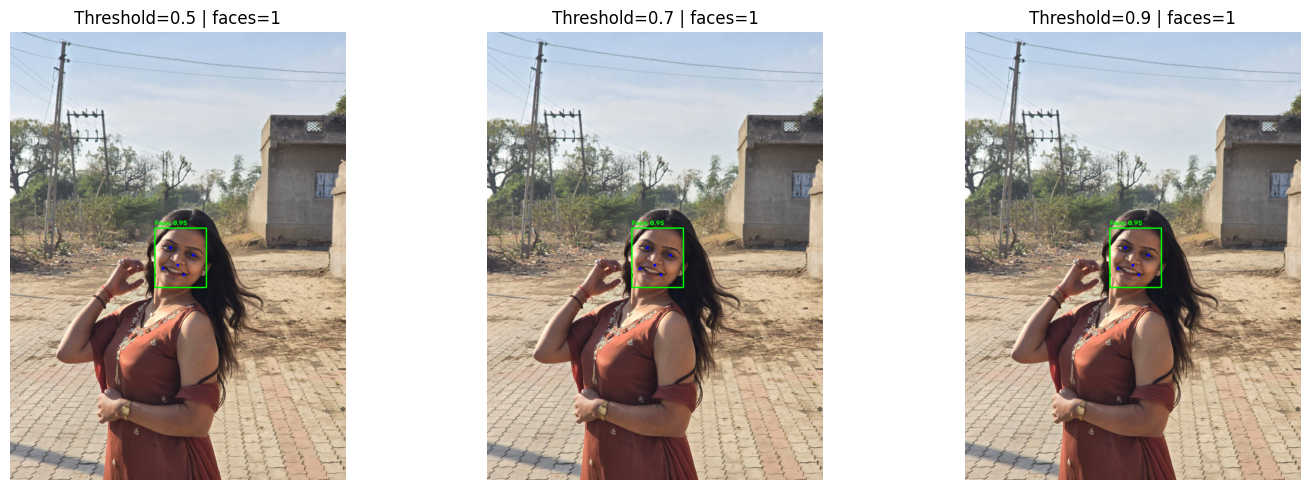

   score_threshold  faces_detected
0              0.5               1
1              0.7               1
2              0.9               1


In [ ]:
# Task 3: confidence threshold experiment
thresholds = [0.5, 0.7, 0.9]

face_files = [
    name for name in ("face1.jpg", "face2.jpg", "face3.jpg")
    if (IMG_DIR / name).exists()
]

if face_files:
    test_face = load_image(face_files[0])
    records = []

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for axis, threshold in zip(axes, thresholds):
        annotated, faces = detect_yunet(test_face, threshold)
        count = 0 if faces is None else len(faces)
        records.append({"score_threshold": threshold, "faces_detected": count})

        axis.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        axis.set_title(f"Threshold {threshold} | Faces {count}")
        axis.axis("off")

    plt.tight_layout()
    save_plot("task3_threshold_experiment.png")
    plt.show()

    threshold_table = pd.DataFrame(records)
    display(threshold_table)
else:
    print("No face1.jpg, face2.jpg or face3.jpg found.")


face1.jpg: shape=(1600, 1200, 3), dtype=uint8
Saved: c:\Deep Learning\PR-3\plots\task3_face_blur.png


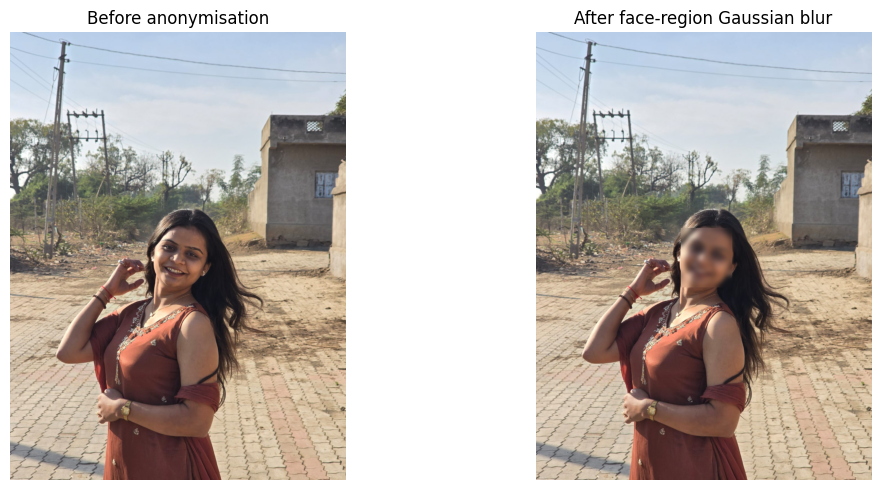

In [ ]:
# Task 3: blur each detected face region
def blur_faces(image, faces, blur_size=51):
    result = image.copy()

    if faces is None:
        return result

    height, width = result.shape[:2]
    kernel = (blur_size, blur_size)

    for face in faces:
        x, y, w, h = face[:4].astype(int)

        left = max(0, x)
        top = max(0, y)
        right = min(width, x + w)
        bottom = min(height, y + h)

        if right > left and bottom > top:
            face_region = result[top:bottom, left:right]
            result[top:bottom, left:right] = cv2.GaussianBlur(face_region, kernel, 0)

    return result

if face_files:
    test_face = load_image(face_files[0])
    detector = make_face_detector(test_face, 0.7)
    _, faces = detector.detect(test_face)
    blurred_face = blur_faces(test_face, faces)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(cv2.cvtColor(test_face, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Before anonymisation")
    axes[1].imshow(cv2.cvtColor(blurred_face, cv2.COLOR_BGR2RGB))
    axes[1].set_title("After face blur")

    for axis in axes:
        axis.axis("off")

    plt.tight_layout()
    save_plot("task3_face_blur.png")
    plt.show()


### Why YuNet?

YuNet is a compact CNN-based face detector exposed in OpenCV through `FaceDetectorYN`. It is designed for efficient face detection and also returns five facial landmarks in the same detection output.

The **score threshold** controls the precision/recall trade-off:

- Lower threshold → more candidate detections, including more possible false positives.
- Higher threshold → fewer, more confident detections, but small/occluded faces may be missed.

For a real-time security camera, a middle/high threshold such as **0.7–0.9** can be a practical starting point, followed by testing on the actual camera environment. For offline photo tagging, a lower threshold may be useful if missing a face is more costly than reviewing false positives.


# Task 4 — Object Detection with YOLOv8n

### Objective
Use pretrained YOLOv8 Nano to detect multiple COCO object classes and study confidence/IoU threshold effects.

### Expected output
Static-image detections, real-time YOLO, confidence/IoU experiments, per-class detection counts and a YOLO explanation.


In [ ]:
# Task 4: load the existing YOLOv8n model
from ultralytics import YOLO

yolo_model = YOLO("yolov8n.pt")
print("YOLOv8n model loaded.")


YOLOv8n loaded.


Saved: c:\Deep Learning\PR-3\plots\task4_yolo_static.png


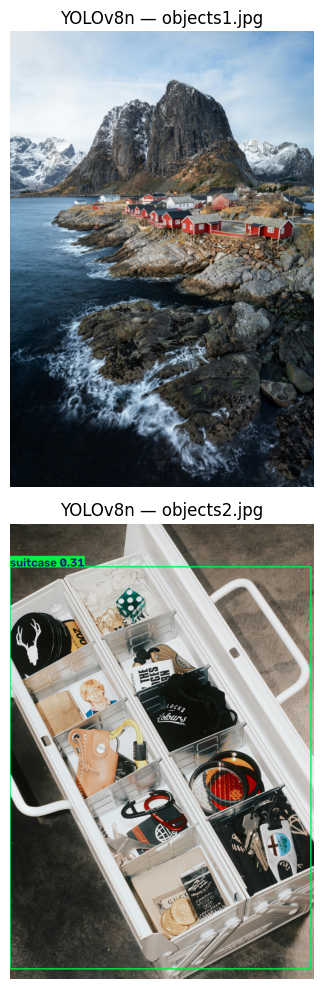

In [ ]:
# Task 4: locate the same object images and run static detection
object_candidates = ["objects1.jpg", "objects2.jpg", "objects3.jpg"]
object_files = [name for name in object_candidates if (IMG_DIR / name).exists()]

if not object_files:
    object_files = [name for name in image_files if "object" in name.lower()][:3]

def draw_yolo_boxes(image, result):
    output = image.copy()

    if result.boxes is None:
        return output

    for box in result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        class_id = int(box.cls[0].item())
        confidence = float(box.conf[0].item())
        label = f"{yolo_model.names[class_id]} {confidence:.2f}"

        cv2.rectangle(output, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(
            output,
            label,
            (x1, max(20, y1 - 7)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (255, 0, 0),
            2
        )

    return output

if object_files:
    fig, axes = plt.subplots(len(object_files), 1, figsize=(14, 5 * len(object_files)))
    axes = np.atleast_1d(axes)

    for axis, filename in zip(axes, object_files):
        prediction = yolo_model.predict(
            source=str(IMG_DIR / filename),
            conf=0.25,
            iou=0.5,
            verbose=False
        )[0]

        annotated = draw_yolo_boxes(load_image(filename), prediction)
        axis.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        axis.set_title(f"YOLOv8n — {filename}")
        axis.axis("off")

    plt.tight_layout()
    save_plot("task4_yolo_static.png")
    plt.show()
else:
    print("No object images found.")


In [ ]:
# Task 4: real-time YOLOv8n detection
def run_yolo_webcam(camera_index=0, conf=0.25, iou=0.5):
    camera = cv2.VideoCapture(camera_index)
    if not camera.isOpened():
        print("Camera could not be opened. Try camera_index=1.")
        return

    fps_history = []

    while True:
        success, frame = camera.read()
        if not success:
            print("Frame could not be read.")
            break

        start = time.perf_counter()

        prediction = yolo_model.predict(
            source=frame,
            conf=conf,
            iou=iou,
            verbose=False
        )[0]

        annotated = draw_yolo_boxes(frame, prediction)
        fps = 1.0 / max(time.perf_counter() - start, 1e-9)
        fps_history.append(fps)

        cv2.putText(
            annotated,
            f"YOLOv8n FPS: {fps:.1f}",
            (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.75,
            (0, 255, 0),
            2
        )

        cv2.imshow("YOLOv8n - Q to quit", annotated)

        if cv2.waitKey(1) & 0xFF in (ord("q"), ord("Q")):
            break

    camera.release()
    cv2.destroyAllWindows()

    if fps_history:
        print(f"Average YOLOv8n FPS: {np.mean(fps_history):.2f}")

# Run manually:
# run_yolo_webcam()


,experiment,value,boxes
0,confidence,0.25,0
1,confidence,0.50,0
2,confidence,0.75,0
3,IoU,0.30,0
4,IoU,0.50,0
5,IoU,0.70,0


Saved: c:\Deep Learning\PR-3\plots\task4_threshold_experiment.png


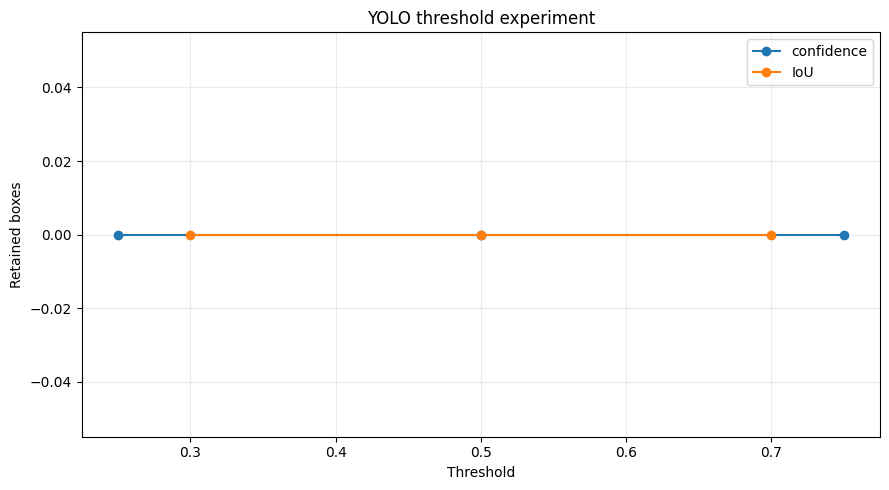

In [ ]:
# Task 4: confidence and IoU experiments
conf_values = [0.25, 0.50, 0.75]
iou_values = [0.30, 0.50, 0.70]

if object_files:
    test_path = str(IMG_DIR / object_files[0])
    experiment_rows = []

    for confidence in conf_values:
        result = yolo_model.predict(
            test_path, conf=confidence, iou=0.5, verbose=False
        )[0]
        experiment_rows.append({
            "experiment": "confidence",
            "value": confidence,
            "boxes": len(result.boxes)
        })

    for iou_threshold in iou_values:
        result = yolo_model.predict(
            test_path, conf=0.25, iou=iou_threshold, verbose=False
        )[0]
        experiment_rows.append({
            "experiment": "IoU",
            "value": iou_threshold,
            "boxes": len(result.boxes)
        })

    threshold_df = pd.DataFrame(experiment_rows)
    display(threshold_df)

    plt.figure(figsize=(9, 5))
    for experiment_name, group in threshold_df.groupby("experiment"):
        plt.plot(group["value"], group["boxes"], marker="o", label=experiment_name)

    plt.xlabel("Threshold")
    plt.ylabel("Retained boxes")
    plt.title("YOLO confidence / IoU experiment")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    save_plot("task4_threshold_experiment.png")
    plt.show()
else:
    print("Add an object image first.")


,class,detections
0,suitcase,1


Saved: c:\Deep Learning\PR-3\plots\task4_per_class_summary.png


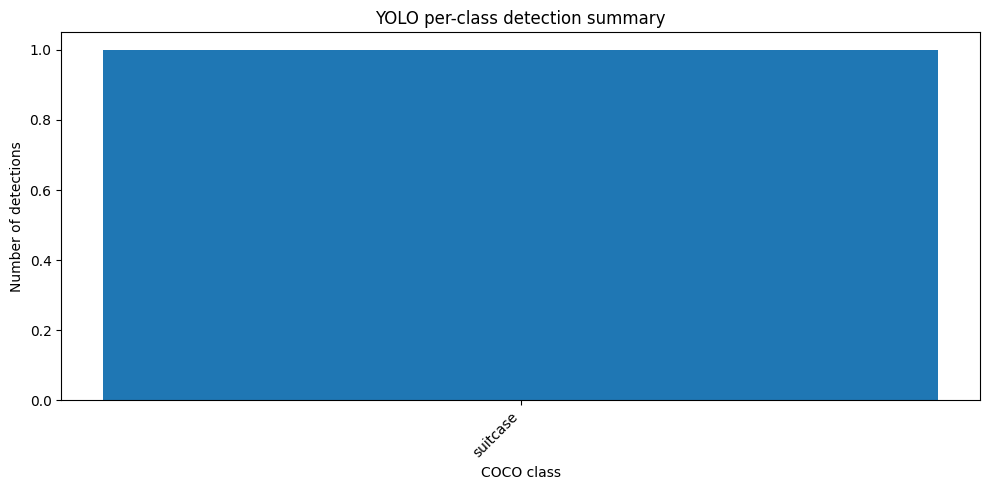

In [ ]:
# Task 4: count detections by object class
class_counts = {}

if object_files:
    for filename in object_files:
        prediction = yolo_model.predict(
            str(IMG_DIR / filename),
            conf=0.25,
            iou=0.5,
            verbose=False
        )[0]

        if prediction.boxes is None:
            continue

        class_ids = prediction.boxes.cls.cpu().numpy().astype(int)
        for class_id in class_ids:
            class_name = yolo_model.names[int(class_id)]
            class_counts[class_name] = class_counts.get(class_name, 0) + 1

    class_df = (
        pd.DataFrame(class_counts.items(), columns=["class", "detections"])
        .sort_values("detections", ascending=False)
        .reset_index(drop=True)
    )

    display(class_df)

    if not class_df.empty:
        plt.figure(figsize=(10, 5))
        plt.bar(class_df["class"], class_df["detections"])
        plt.xlabel("COCO class")
        plt.ylabel("Number of detections")
        plt.title("YOLO per-class detection summary")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        save_plot("task4_per_class_summary.png")
        plt.show()
else:
    print("Add object images first.")


### Why YOLO generalises

YOLO is a **single-stage object detector**. Instead of using a separate proposal stage followed by classification, it predicts object locations and class probabilities in one forward inference pipeline, followed by post-processing such as Non-Maximum Suppression (NMS).

**YOLOv8n (Nano)** is designed for speed and lower computation. Larger variants such as **YOLOv8s/m/l/x** generally provide more capacity and can improve accuracy, but they require more computation and memory.

The pretrained COCO model can recognise **80 object classes**, so one model can detect many everyday objects without training a separate model for each class.


# Task 5 — Integrated Pipeline & Final Comparison

### Objective
Combine YuNet face detection and YOLO object detection on the same webcam stream and compare their speed.

### Expected output
One integrated live stream, separate/combined FPS measurements, a comparison table and a final deployment reflection.


In [ ]:
# Task 5: integrated YuNet + YOLOv8n webcam pipeline
def run_integrated_webcam(
    camera_index=0,
    face_threshold=0.7,
    yolo_conf=0.25,
    yolo_iou=0.5
):
    camera = cv2.VideoCapture(camera_index)
    if not camera.isOpened():
        print("Camera could not be opened.")
        return

    face_detector = None
    fps_history = []

    while True:
        success, frame = camera.read()
        if not success:
            print("Frame could not be read.")
            break

        start = time.perf_counter()

        # Face branch
        if face_detector is None:
            face_detector = make_face_detector(frame, face_threshold)
        face_detector.setInputSize((frame.shape[1], frame.shape[0]))

        _, faces = face_detector.detect(frame)
        combined, face_count = annotate_faces(frame, faces)

        # Object branch
        object_result = yolo_model.predict(
            source=frame,
            conf=yolo_conf,
            iou=yolo_iou,
            verbose=False
        )[0]

        # Draw object boxes on top of the face annotations.
        combined = draw_yolo_boxes(combined, object_result)

        fps = 1.0 / max(time.perf_counter() - start, 1e-9)
        fps_history.append(fps)

        cv2.putText(
            combined,
            f"Faces: {face_count} | Objects: {len(object_result.boxes)} | FPS: {fps:.1f}",
            (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.65,
            (0, 255, 0),
            2
        )

        cv2.imshow("YuNet + YOLOv8n - Q to quit", combined)

        if cv2.waitKey(1) & 0xFF in (ord("q"), ord("Q")):
            break

    camera.release()
    cv2.destroyAllWindows()

    if fps_history:
        print(f"Average integrated FPS: {np.mean(fps_history):.2f}")

# Run manually:
# run_integrated_webcam()


In [ ]:
# Task 5: FPS benchmark helpers
def benchmark_yunet(camera_index=0, seconds=10, threshold=0.7):
    camera = cv2.VideoCapture(camera_index)
    if not camera.isOpened():
        return np.nan

    detector = None
    frame_count = 0
    started = time.perf_counter()

    while time.perf_counter() - started < seconds:
        success, frame = camera.read()
        if not success:
            break

        if detector is None:
            detector = make_face_detector(frame, threshold)
        detector.setInputSize((frame.shape[1], frame.shape[0]))
        detector.detect(frame)
        frame_count += 1

    elapsed = time.perf_counter() - started
    camera.release()
    return frame_count / max(elapsed, 1e-9)

def benchmark_yolo(camera_index=0, seconds=10, conf=0.25, iou=0.5):
    camera = cv2.VideoCapture(camera_index)
    if not camera.isOpened():
        return np.nan

    frame_count = 0
    started = time.perf_counter()

    while time.perf_counter() - started < seconds:
        success, frame = camera.read()
        if not success:
            break

        yolo_model.predict(frame, conf=conf, iou=iou, verbose=False)
        frame_count += 1

    elapsed = time.perf_counter() - started
    camera.release()
    return frame_count / max(elapsed, 1e-9)

def benchmark_integrated(camera_index=0, seconds=10, face_threshold=0.7, conf=0.25, iou=0.5):
    camera = cv2.VideoCapture(camera_index)
    if not camera.isOpened():
        return np.nan

    detector = None
    frame_count = 0
    started = time.perf_counter()

    while time.perf_counter() - started < seconds:
        success, frame = camera.read()
        if not success:
            break

        if detector is None:
            detector = make_face_detector(frame, face_threshold)
        detector.setInputSize((frame.shape[1], frame.shape[0]))
        detector.detect(frame)
        yolo_model.predict(frame, conf=conf, iou=iou, verbose=False)
        frame_count += 1

    elapsed = time.perf_counter() - started
    camera.release()
    return frame_count / max(elapsed, 1e-9)

# Keep benchmarking opt-in so opening the notebook does not start three cameras.
fps_results = pd.DataFrame({
    "Technique": ["YuNet face", "YOLOv8n", "Integrated YuNet + YOLO"],
    "FPS": [np.nan, np.nan, np.nan]
})

display(fps_results)

# For real measurements, run:
# fps_results.loc[0, "FPS"] = benchmark_yunet()
# fps_results.loc[1, "FPS"] = benchmark_yolo()
# fps_results.loc[2, "FPS"] = benchmark_integrated()
# display(fps_results)


,Technique,FPS
0,YuNet face,0
1,YOLOv8n,0
2,Integrated YuNet + YOLO,0


Saved: c:\Deep Learning\PR-3\plots\task5_fps_comparison.png


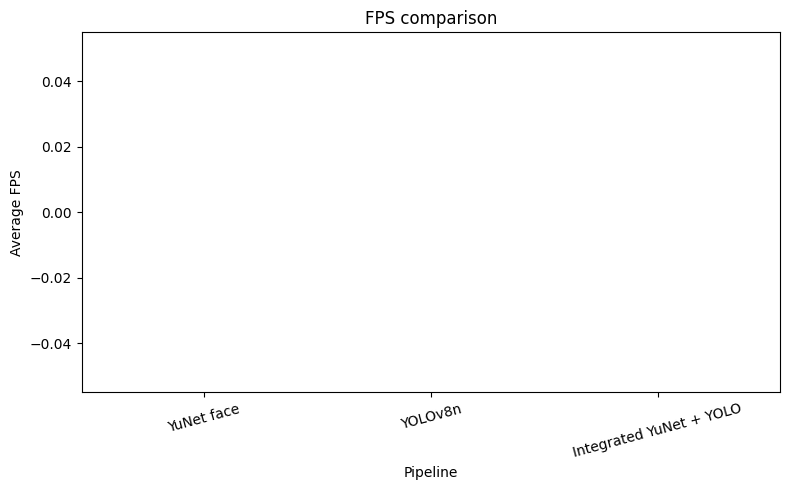

In [30]:
# Task 5: visualise the measured FPS values
plot_data = fps_results.dropna(subset=["FPS"])

plt.figure(figsize=(8, 5))
if not plot_data.empty:
    plt.bar(plot_data["Technique"], plot_data["FPS"])
else:
    plt.text(
        0.5, 0.5,
        "Run the benchmark cells to populate FPS values",
        ha="center", va="center"
    )
    plt.xticks([])

plt.xlabel("Pipeline")
plt.ylabel("Average FPS")
plt.title("FPS comparison")
plt.xticks(rotation=15)
plt.tight_layout()
save_plot("task5_fps_comparison.png")
plt.show()


In [ ]:
# Final comparison table
comparison_rows = [
    ["Morphology", "Classical", "Binary shapes / mask regions",
     "Low–medium", "Very high / operation dependent",
     "Noise removal and mask cleanup"],

    ["Bitwise operations", "Classical", "Logical mask regions",
     "Low", "Very high",
     "Masking, compositing and ROI extraction"],

    ["Histograms + alpha/beta", "Classical", "Not a detector",
     "Diagnostic tool", "Very high",
     "Brightness/contrast analysis and preprocessing"],

    ["YuNet", "Deep Learning", "Faces + 5 landmarks",
     "Medium–high", "Measure on your system",
     "Real-time face detection"],

    ["YOLOv8n", "Deep Learning", "80 COCO object classes",
     "Medium–high", "Measure on your system",
     "General real-time object detection"],
]

comparison = pd.DataFrame(
    comparison_rows,
    columns=[
        "Technique", "Type", "Detects", "Lighting robustness",
        "Approx. FPS", "Best use case"
    ]
)

display(comparison)
comparison.to_csv(PLOTS_DIR / "final_comparison.csv", index=False)
print("Saved comparison:", PLOTS_DIR / "final_comparison.csv")


,Technique,Type,Detects,Lighting robustness,Approx. FPS,Best use case
0,Morphology,Classical,Binary shapes / mask regions,Low–medium,Very high / image-operation dependent,Noise removal and mask cleanup
1,Bitwise operations,Classical,Logical mask regions,Low,Very high,"Masking, compositing and ROI extraction"
2,Histograms + alpha/beta,Classical,Not a detector,Diagnostic tool,Very high,Brightness/contrast analysis and preprocessing
3,YuNet,Deep Learning,Faces + 5 landmarks,Medium–high,Measure on your system,Real-time face detection
4,YOLOv8n,Deep Learning,80 COCO object classes,Medium–high,Measure on your system,General real-time object detection


## Final reflection — model answer

For a **real-time monitoring system**, a good accuracy-to-computation approach is to use inexpensive classical preprocessing only when it is actually needed, followed by a compact deep-learning detector. For face-focused monitoring, **YuNet** is appropriate because it is lightweight and directly provides facial landmarks. For general objects, **YOLOv8n** provides broad COCO-class coverage.

For a **low-power edge device**, I would first keep YOLOv8n and optimise camera resolution, confidence threshold and preprocessing. If more accuracy is required and the hardware can support it, I would test YOLOv8s. For a cloud/server deployment, a larger YOLO model can be considered because computation and memory constraints are less restrictive.

The final choice should be based on **measured FPS, detection accuracy, false positives and the actual camera environment**, rather than assuming one threshold or model is best for every system.
